# Grid parsing splink for various dataset seeds.

In [1]:
import pandas as pd

import os, sys

# ---- 1️⃣ Find the directory that holds the `em_pipeline` package ----
# Start from the notebook’s directory (or the current working directory)
start = os.path.abspath(os.getcwd())
if "__file__" in globals():                     # works when run as a script
    start = os.path.abspath(os.path.dirname(__file__))

# Walk up the tree until we see a folder called `em_pipeline`
repo_root = start
while True:
    if os.path.isdir(os.path.join(repo_root, "em_pipeline")):
        break                                   # we found it
    parent = os.path.dirname(repo_root)
    if parent == repo_root:                     # reached filesystem root → give up
        raise RuntimeError("Could not find a directory containing 'em_pipeline'")
    repo_root = parent

# ---- 2️⃣ Insert it at the front of sys.path (if not already there) ----
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


from em_pipeline.data_loader import (
    load_pair_dfs_from_paths, 
    standardise_dt, 
    plot_numerical_distribution,
)
from em_pipeline.splink_helper import (
    build_api_with_con,
    get_blocking_rules,
    get_estimating_blocking_rules,
    get_numerical_comparison,
    get_datetime_comparison,
    get_category_comparison,
    train_linker,
    visualise_data,
)
from splink import DuckDBAPI, Linker, SettingsCreator

In [2]:
DF1_PATH = os.path.join("..", "..", "grid_output_data", "o50", "o50_a.parquet")
DF2_PATH = os.path.join("..", "..", "grid_output_data", "o50", "o50_b.parquet")

# DuckDB resource limits (same as in the original notebook)
MEM_LIMIT  = "'24GB'"
TEMP_DIR   = "'./duckdb_spill_dir.tmp'"

# Column names used in the synthetic dataset
LEFT_ID_COL   = "local_source_id"      # appears in both df1 & df2 after loading
RIGHT_ID_COL  = "local_source_id"
UNIQUE_ID_COL = "latent_event_id"      # used for labeling / de‑duplication
CATEGORICAL_COL   = "categorical"
NUMERIC_COL       = "numerical_noisy"
DATETIME_COL      = "datetime_noisy"

# How strict we want the initial random‑match estimate to be
RECALL_FOR_PRIOR = 0.99   # same as the original notebook

In [3]:
df1, df2 = load_pair_dfs_from_paths(DF1_PATH, DF2_PATH)
print(f"cartesian prod: {len(df1) * len(df2)}")

cartesian prod: 15951195


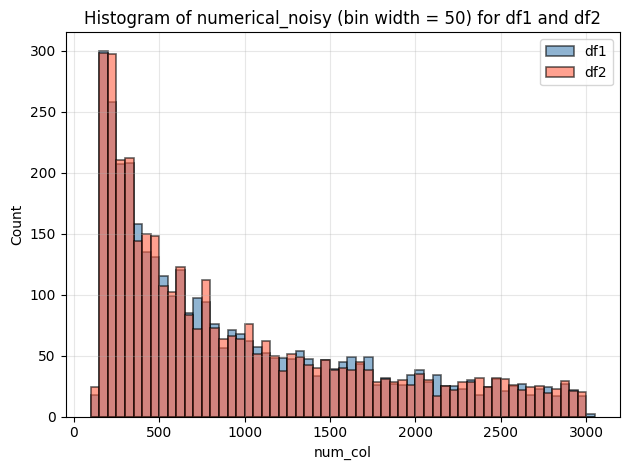

In [4]:
plot_numerical_distribution(df1, df2, "numerical_noisy")

In [5]:
standardise_dt(df1, df2, DATETIME_COL)

Set datetime_noisy to date for both df1 and df2.


In [6]:
from splink.exploratory import profile_columns

db_api = build_api_with_con(MEM_LIMIT, TEMP_DIR)

profile_columns(
    [df1, df2],
    db_api=db_api,
    column_expressions=[
        "categorical",
        "datetime_noisy",
        "numerical_noisy",
    ],
)

alt.VConcatChart(...)

In [7]:
from splink.blocking_analysis import (
    cumulative_comparisons_to_be_scored_from_blocking_rules_chart
)

brs = get_blocking_rules()

cumulative_comparisons_to_be_scored_from_blocking_rules_chart(
    table_or_tables=[df1, df2],
    blocking_rules=brs,
    db_api=db_api,
    link_type="link_only",
    unique_id_column_name="latent_event_id"
)

alt.Chart(...)

In [8]:
# We retain the same comparison levels.
numerical_noisy_comparison = get_numerical_comparison(num_col=NUMERIC_COL)
datetime_noisy_comparison = get_datetime_comparison(dt_col=DATETIME_COL)
categorical_comparison = get_category_comparison(cat_col=CATEGORICAL_COL)

settings = SettingsCreator(
    link_type="link_only", 
    unique_id_column_name="latent_event_id",
    blocking_rules_to_generate_predictions=brs,
    comparisons=[
        numerical_noisy_comparison,
        categorical_comparison,
        datetime_noisy_comparison
    ],
    retain_intermediate_calculation_columns=True,
    additional_columns_to_retain=["local_source_id", "global_entity_id"],
)

linker = Linker(
    [df1, df2],
    settings,
    db_api=db_api
)

In [9]:
train_linker(linker, RECALL_FOR_PRIOR)

Probability two random records match is estimated to be  0.000147.
This means that amongst all possible pairwise record comparisons, one in 6,824.41 are expected to match.  With 15,951,195 total possible comparisons, we expect a total of around 2,337.37 matching pairs
----- Estimating u probabilities using random sampling -----


Initialising training...



Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - numerical_noisy (no m values are trained).
    - categorical (no m values are trained).
    - datetime_noisy (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
abs(epoch(l.datetime_noisy::TIMESTAMP) - epoch(r.datetime_noisy::TIMESTAMP)) <= 86400

Parameter estimates will be made for the following comparison(s):
    - numerical_noisy
    - categorical

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - datetime_noisy

Iteration 1: Largest change in params was -0.0358 in the m_probability of categorical, level `All other comparisons`
Iteration 2: Largest change in params was 0.00975 in the m_probability of categorical, level `Exact match on categorical`
Iteration 3: Largest change in params was -0.00255 in the m_probability of cate

Training done.


In [10]:
df_predict = linker.inference.predict()

Blocking time: 16.10 seconds
Predict time: 2.93 seconds


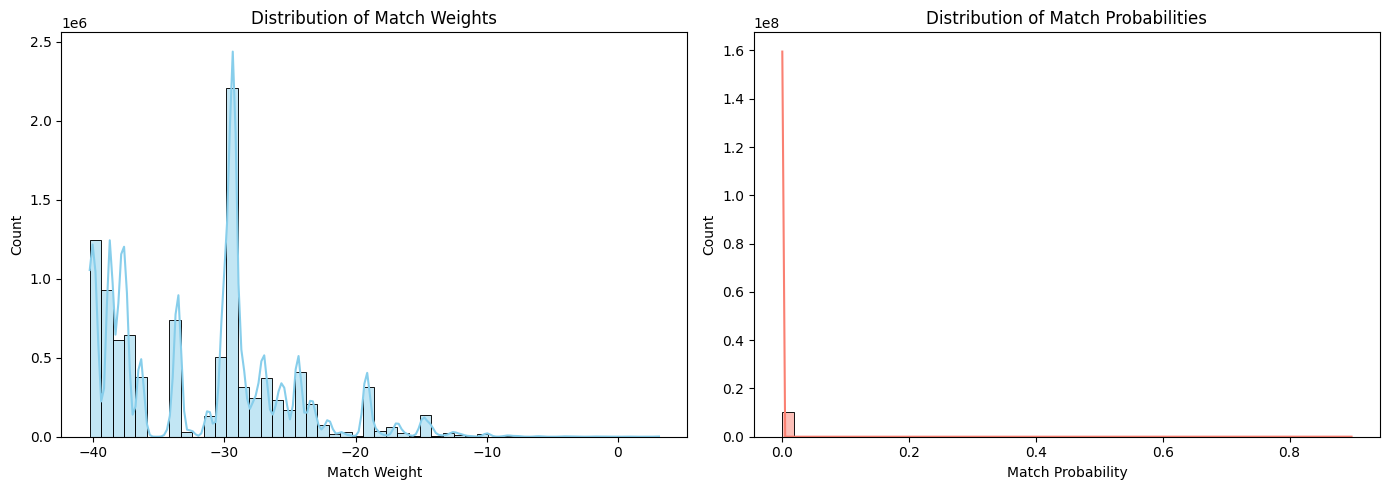

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the Splink object is converted to a Pandas DataFrame
df_pandas = df_predict.as_pandas_dataframe()

# Create a two-panel distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution (Linear scale, e.g., -10 to +30)
sns.histplot(data=df_pandas, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=df_pandas, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()


In [ ]:
# We want to do the following analysis: check the distribution of match probabilities for pairs where the latent_event_id matches vs. those where it does not match.
df_predict_pd = df_predict.as_pandas_dataframe()

matches = df_predict_pd[df_predict_pd["latent_event_id_l"] == df_predict_pd["latent_event_id_r"]]
non_matches = df_predict_pd[df_predict_pd["latent_event_id_l"] != df_predict_pd["latent_event_id_r"]]

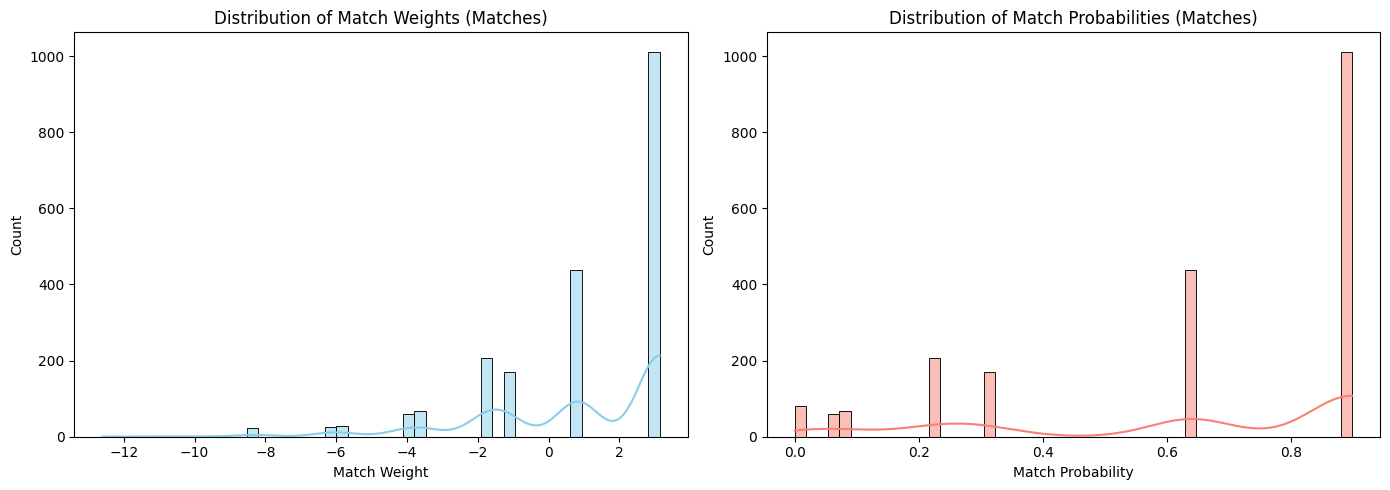

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution
sns.histplot(data=matches, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights (Matches)")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=matches, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities (Matches)")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

# ==========================================
# STEP 1: Discover Splink's Internal Dataset Names
# ==========================================
# Get the exact keys Splink uses internally to label the left and right datasets
dataset_names = list(linker._input_tables_dict.keys())
print(f"DEBUG: Splink recognizes your datasets as: {dataset_names}")

# Assign them cleanly based on their registration sequence
internal_name_df1 = dataset_names[0]
internal_name_df2 = dataset_names[1]


# ==========================================
# STEP 2: Standardise and Extract Common Identifiers
# ==========================================
# Get common IDs and ensure they are read purely as identical string types
ids_df1 = df1[['latent_event_id']].copy().rename(columns={'latent_event_id': 'latent_event_id_l'})
ids_df2 = df2[['latent_event_id']].copy().rename(columns={'latent_event_id': 'latent_event_id_r'})

raw_matches = ids_df1.merge(ids_df2, left_on='latent_event_id_l', right_on='latent_event_id_r')


# ==========================================
# STEP 3: Enforce Exact Splink Alphabetical Left-Right Sort Order
# ==========================================
labels_df = pd.DataFrame()
labels_df["latent_event_id_l"] = raw_matches["latent_event_id_l"]
labels_df["latent_event_id_r"] = raw_matches["latent_event_id_r"]
labels_df["source_dataset_l"] = internal_name_df1
labels_df["source_dataset_r"] = internal_name_df2
labels_df["clerical_match_score"] = 1.0

# Splink drops labels if concat(source_l, id_l) > concat(source_r, id_r)
concat_l = labels_df["source_dataset_l"] + "-__-" + labels_df["latent_event_id_l"]
concat_r = labels_df["source_dataset_r"] + "-__-" + labels_df["latent_event_id_r"]
swap_mask = concat_l > concat_r

if swap_mask.any():
    # Correct source datasets orientation
    labels_df.loc[swap_mask, ["source_dataset_l", "source_dataset_r"]] = \
        labels_df.loc[swap_mask, ["source_dataset_r", "source_dataset_l"]].values
    # Correct corresponding ID orientation
    labels_df.loc[swap_mask, ["latent_event_id_l", "latent_event_id_r"]] = \
        labels_df.loc[swap_mask, ["latent_event_id_r", "latent_event_id_l"]].values


# ==========================================
# STEP 4: Safely Overwrite and Register Table Pointers
# ==========================================
try:
    linker.misc.query_sql("DROP TABLE IF EXISTS my_ground_truth_labels")
except Exception:
    pass

labels_table = linker.table_management.register_labels_table(labels_df, overwrite=True)
print(f"Success: Registered {len(labels_df)} ground-truth rows with Splink's structural format.")


# ==========================================
# STEP 5: Force Prediction & Extract Accuracy Metrics
# ==========================================
# Ensure a prediction pass has run so intermediate tables are active
print("Calculating link pairs...")
pred = linker.inference.predict() 

# Extract the metrics
try:
    roc_metrics_df = linker.evaluation.accuracy_analysis_from_labels_table(
        labels_table, 
        output_type="table",
        add_metrics=["f1", "accuracy"]
    ).as_pandas_dataframe()
    
    print(f"Evaluation succeeded! Rows generated: {len(roc_metrics_df)}")
except Exception as err:
    print(f"Failed during evaluation compilation: {err}")


'CREATE TABLE __splink__df_sql_query_6984dd6e5 AS 
DROP TABLE IF EXISTS my_ground_truth_labels' contains unsupported syntax. Falling back to parsing as a 'Command'.


DEBUG: Splink recognizes your datasets as: ['__splink__input_table_0', '__splink__input_table_1']
Success: Registered 2035 ground-truth rows with Splink's structural format.
Calculating link pairs...


Blocking time: 13.53 seconds
Predict time: 0.10 seconds


Evaluation succeeded! Rows generated: 12


In [12]:
linker.evaluation.accuracy_analysis_from_labels_table(
    labels_table, 
    add_metrics=["f1", "accuracy"],
    output_type="threshold_selection"
)


alt.HConcatChart(...)

In [15]:
left_counts  = df1["local_source_id"].value_counts()   # Series: id → frequency in df1
right_counts = df2["local_source_id"].value_counts()   # Series: id → frequency in df2

agg_df = (
    df_predict_pd[
        ['local_source_id_l', 'local_source_id_r','match_probability']
    ]
    .groupby(['local_source_id_l', 'local_source_id_r'], as_index=False)
    .agg({'match_probability': sum})
)

agg_df

/tmp/ipykernel_1520803/3828851778.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'match_probability': sum})


,local_source_id_l,local_source_id_r,match_probability
0,DF1_100000,DF1_100000,58.483758
1,DF1_100000,DF1_100002,0.347302
2,DF1_100000,DF1_100004,0.201548
3,DF1_100000,DF1_100006,0.423661
4,DF1_100000,DF1_100012,0.121492
...,...,...,...
2495,DF1_100074,DF2_100055,0.154884
2496,DF1_100074,DF2_100057,0.003029
2497,DF1_100074,DF2_100063,0.245032
2498,DF1_100074,DF2_100071,0.250107


In [16]:
unique_l = left_counts.index
unique_r = right_counts.index

# Cartesian product of the observed ids (still a DataFrame)
pair_keys = pd.MultiIndex.from_product(
    [unique_l, unique_r],
    names=["local_source_id_l", "local_source_id_r"]
).to_frame(index=False)

# Attach the left and right counts
pair_keys = pair_keys.merge(
    left_counts.rename("left_count"),
    left_on="local_source_id_l",
    right_index=True,
    how="left"
).merge(
    right_counts.rename("right_count"),
    left_on="local_source_id_r",
    right_index=True,
    how="left"
)

# Pair‑specific denominator = left_count × right_count
pair_keys["pair_size"] = pair_keys["left_count"] * pair_keys["right_count"]

# -------------------------------------------------
# 4️⃣  Join the aggregated probabilities to the pair‑specific sizes
# -------------------------------------------------
norm_df = pair_keys.merge(
    agg_df,
    on=["local_source_id_l", "local_source_id_r"],
    how="left"               # keep all pairs; missing probabilities become NaN
)

norm_df["norm_match_prob"] = norm_df["match_probability"] / norm_df["pair_size"]

norm_df

,local_source_id_l,local_source_id_r,left_count,right_count,pair_size,match_probability,norm_match_prob
0,DF1_100020,DF2_100037,126,132,16632,1.094640,6.581532e-05
1,DF1_100020,DF2_100042,126,124,15624,0.761549,4.874226e-05
2,DF1_100020,DF1_100051,126,124,15624,0.196246,1.256053e-05
3,DF1_100020,DF1_100054,126,121,15246,2.012928,1.320299e-04
4,DF1_100020,DF1_100052,126,111,13986,0.267517,1.912749e-05
...,...,...,...,...,...,...,...
2495,DF1_100016,DF2_100057,21,53,1113,0.001253,1.125904e-06
2496,DF1_100016,DF2_100018,21,52,1092,0.000116,1.063251e-07
2497,DF1_100016,DF2_100021,21,30,630,0.018896,2.999410e-05
2498,DF1_100016,DF1_100053,21,27,567,0.057508,1.014256e-04


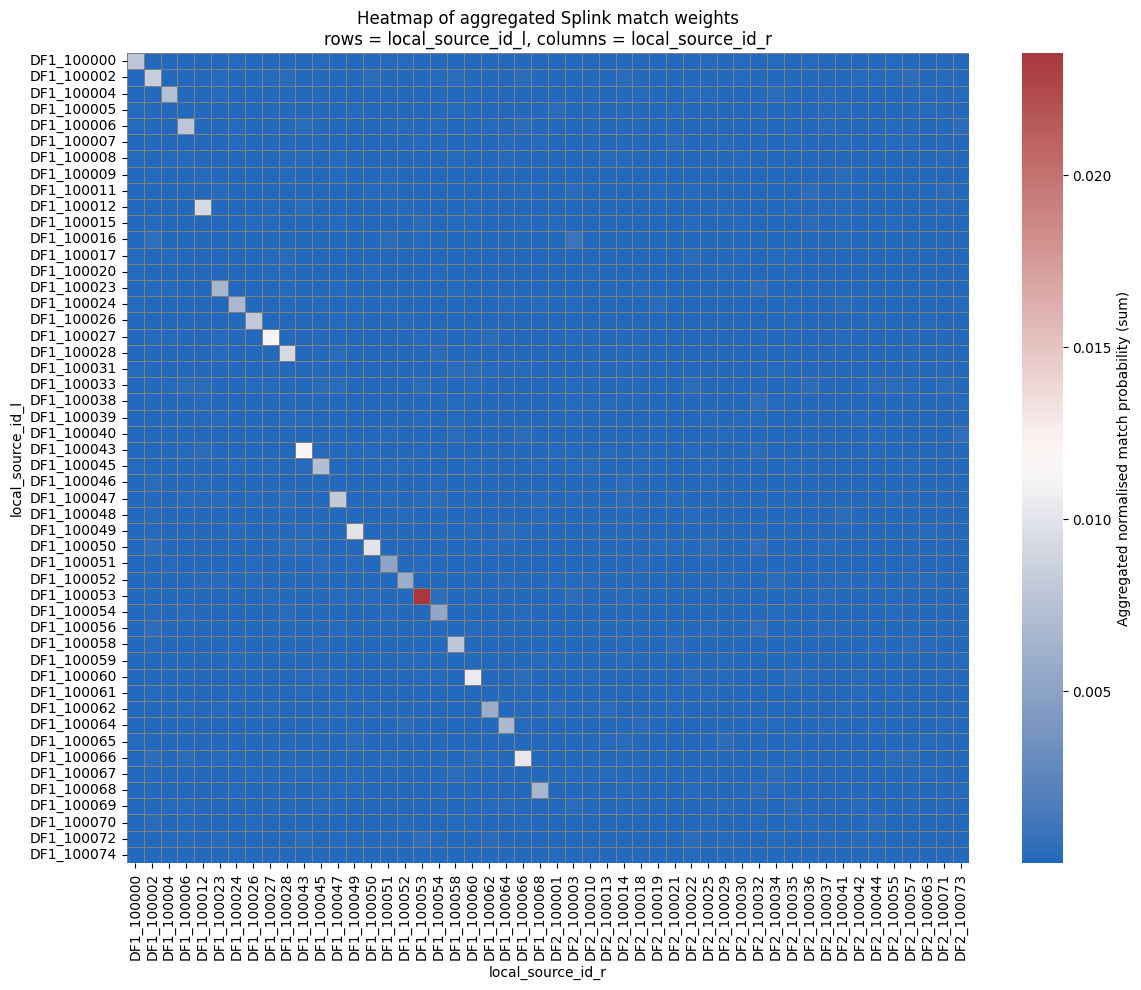

In [17]:
mat = norm_df.pivot(
    index = 'local_source_id_l',
    columns = 'local_source_id_r',
    values = 'norm_match_prob'
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    mat,
    cmap='vlag',           # diverging colormap; change if you prefer another
    mask=mat.isna(),       # hide missing cells (pairs with no observations)
    linewidths=.5,
    linecolor='gray',
    cbar_kws={'label': 'Aggregated normalised match probability (sum)'}
)
plt.title('Heatmap of aggregated Splink match weights\n'
          'rows = local_source_id_l, columns = local_source_id_r')
plt.xlabel('local_source_id_r')
plt.ylabel('local_source_id_l')
plt.tight_layout()
plt.show()